# 01 Attribution audit
**Question:** how much revenue do the platforms claim, how does it compare with actual revenue, and what do the dashboards hide?

*Prakriti Foods is fictional; all data is synthetic.*

In [1]:
import duckdb, matplotlib.pyplot as plt
con = duckdb.connect()
for t in ['weekly_geo','platform_reported','customers','orders','influencers']:
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM read_csv_auto('../data/generated/{t}.csv')")
q = lambda s: con.execute(s).df()

## 1. What the platforms claim

In [2]:
claims = q('''SELECT channel,
       ROUND(SUM(spend_lakh)/100, 1)            AS spend_cr,
       ROUND(SUM(platform_revenue_lakh)/100, 1) AS claimed_revenue_cr,
       ROUND(SUM(platform_revenue_lakh)/SUM(spend_lakh), 2) AS platform_roas
FROM platform_reported GROUP BY channel ORDER BY claimed_revenue_cr DESC''')
claims

,channel,spend_cr,claimed_revenue_cr,platform_roas
0,QC_Ads,11.5,50.4,4.40
1,Meta,11.9,36.1,3.03
2,Google_Search,6.7,21.0,3.15
3,YouTube,5.2,7.2,1.40
4,Influencers,4.3,4.6,1.06


In [3]:
tot = q('''SELECT ROUND((SELECT SUM(platform_revenue_lakh) FROM platform_reported)/100, 1) AS claimed_cr,
       ROUND((SELECT SUM(revenue_lakh) FROM weekly_geo)/100, 1)            AS actual_cr,
       ROUND((SELECT SUM(spend_lakh) FROM platform_reported)/100 + (SELECT SUM(spend_Trade_Promo_lakh) FROM weekly_geo)/100, 1) AS paid_spend_cr''')
tot

,claimed_cr,actual_cr,paid_spend_cr
0,119.3,181.8,45.4


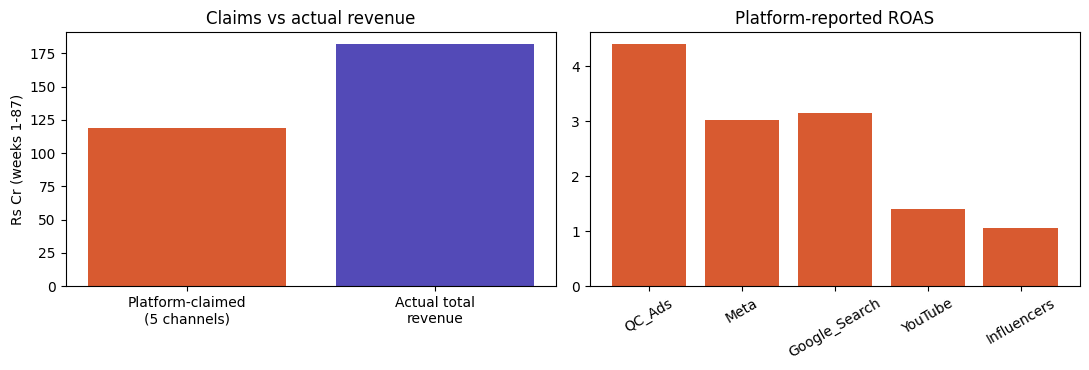

In [4]:
claimed, actual = tot.claimed_cr[0], tot.actual_cr[0]
fig, ax = plt.subplots(1,2, figsize=(11,3.8))
ax[0].bar(['Platform-claimed\n(5 channels)','Actual total\nrevenue'], [claimed, actual], color=['#D85A30','#534AB7'])
ax[0].set_ylabel('Rs Cr (weeks 1-87)'); ax[0].set_title('Claims vs actual revenue')
ax[1].bar(claims.channel, claims.platform_roas, color='#D85A30'); ax[1].set_title('Platform-reported ROAS'); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 2. Where the claims are concentrated

In [5]:
q('''SELECT channel,
       ROUND(100*SUM(spend_lakh)/SUM(SUM(spend_lakh)) OVER (), 1) AS pct_of_spend,
       ROUND(100*SUM(platform_revenue_lakh)/SUM(SUM(platform_revenue_lakh)) OVER (), 1) AS pct_of_claims
FROM platform_reported GROUP BY channel ORDER BY pct_of_claims DESC''')

,channel,pct_of_spend,pct_of_claims
0,QC_Ads,29.0,42.3
1,Meta,30.1,30.2
2,Google_Search,16.8,17.6
3,YouTube,13.1,6.1
4,Influencers,10.9,3.9


## 3. Customer quality the dashboards do not show

In [6]:
q('''WITH frac AS (SELECT (SELECT COUNT(*) FROM customers)*1.0/(SELECT SUM(new_customers) FROM weekly_geo) AS f),
spend AS (
  SELECT 'Meta' ch, SUM(spend_Meta_lakh) s FROM weekly_geo UNION ALL
  SELECT 'Google_Search', SUM(spend_Google_Search_lakh) FROM weekly_geo UNION ALL
  SELECT 'YouTube', SUM(spend_YouTube_lakh) FROM weekly_geo UNION ALL
  SELECT 'Influencers', SUM(spend_Influencers_lakh) FROM weekly_geo UNION ALL
  SELECT 'Trade_Promo', SUM(spend_Trade_Promo_lakh) FROM weekly_geo),
cust AS (SELECT acquisition_channel ch, COUNT(*) n FROM customers GROUP BY 1)
SELECT spend.ch AS channel, ROUND(cust.n/frac.f) AS est_new_customers,
       ROUND(spend.s*1e5/(cust.n/frac.f)) AS gross_cac_rs
FROM spend JOIN cust USING (ch), frac ORDER BY gross_cac_rs''')

,channel,est_new_customers,gross_cac_rs
0,Influencers,15832.0,2735.0
1,YouTube,16694.0,3111.0
2,Meta,37670.0,3171.0
3,Google_Search,14800.0,4505.0
4,Trade_Promo,11473.0,5097.0


In [7]:
q('''WITH firsts AS (SELECT customer_id, MIN(date) fd FROM orders GROUP BY 1),
elig AS (SELECT c.customer_id, c.acquisition_channel ch, f.fd FROM customers c JOIN firsts f USING (customer_id)
         WHERE f.fd <= (SELECT MAX(date) FROM orders) - INTERVAL 90 DAY)
SELECT ch AS channel, COUNT(*) AS customers,
       ROUND(AVG(CASE WHEN EXISTS (SELECT 1 FROM orders o WHERE o.customer_id = elig.customer_id
                        AND o.date > elig.fd AND o.date <= elig.fd + INTERVAL 90 DAY) THEN 1.0 ELSE 0.0 END), 3) AS repeat_90d
FROM elig GROUP BY ch ORDER BY repeat_90d DESC''')

,channel,customers,repeat_90d
0,Influencers,844,0.419
1,YouTube,880,0.399
2,Organic,11958,0.398
3,Google_Search,794,0.335
4,Meta,1990,0.306
5,Trade_Promo,621,0.225


*Caveat:* gross CAC divides each channel's whole spend by website customers only, so it overstates true CAC for channels that also drive quick-commerce and marketplace sales. Treat it as a ranking aid, not a benchmark comparison. Customers are a ~10% ledger sample scaled up by the share of weekly new customers.

## Answer

In [8]:
print(f"Platforms claim Rs {claimed:.0f} Cr, which is {claimed/actual:.0%} of actual revenue (Rs {actual:.0f} Cr). "
      f"They are NOT over-claiming in total on these ranges, so the problem is not 'claims exceed revenue'; "
      f"it is that 'claims' are not incremental: the quick-commerce and Meta/Google dashboards show ROAS of 3-4.4x, "
      f"while YouTube and influencers show only {claims.platform_roas.min():.1f}-1.4x yet bring the best repeat buyers. "
      f"Whether the 3-4x is real is exactly what the MMM and the geo experiment must test (the planted truth stays sealed).")

Platforms claim Rs 119 Cr, which is 66% of actual revenue (Rs 182 Cr). They are NOT over-claiming in total on these ranges, so the problem is not 'claims exceed revenue'; it is that 'claims' are not incremental: the quick-commerce and Meta/Google dashboards show ROAS of 3-4.4x, while YouTube and influencers show only 1.1-1.4x yet bring the best repeat buyers. Whether the 3-4x is real is exactly what the MMM and the geo experiment must test (the planted truth stays sealed).
